**Tutorial for using energydiff with the example dataset of GridFM**
==================================================================

This tutorial explains how to use EnergyDiff with a dataset of one node and is meant to evolve with covariables and especially a temperature covariable in the future.

Pre-requisites
-------------
If you haven't already, please download a dataset of power/energy consumption with a hourly resolution and a temperature feature. An example is available in gridfm/streaming_data.ipynb.

In [2]:
# Importing dependencies

import os
import logging

logger = logging.getLogger(__name__)

## Loading data

In [ ]:
from pathlib import Path
from opensynth.data_modules.gridfm_data_module import GridFMDataModule
import pytorch_lightning as pl

data_path = Path("../../data/processed/historical/train/data.csv")
stats_path = Path("../../data/processed/historical/train/mean_std.csv")
holdout_data_path = Path("../../data/processed/historical/holdout/data.csv")

# The dataset is small so we define n_training_samples with the maximum number of training samples
batch_size = 64
n_training_samples = 1584

dm = GridFMDataModule(data_path=data_path, stats_path=stats_path, batch_size=batch_size, n_samples=n_training_samples)
dm.setup()

## Diffusion Module

In [4]:
from opensynth.models.energydiff import diffusion

df_model = diffusion.PLDiffusion1D(
    dim_base=128,
    dim_in=1,
    num_attn_head=4,
    num_decoder_layer=12,
    dim_feedforward=512,
    dropout=0.1,
    learn_variance=False,
    num_timestep=1000,
    model_mean_type=diffusion.ModelMeanType.V,
    model_variance_type=diffusion.ModelVarianceType.FIXED_SMALL,
    loss_type=diffusion.LossType.MSE,
    beta_schedule_type=diffusion.BetaScheduleType.COSINE,
    lr=1e-4,
    ema_update_every=1,
    ema_decay=0.999,
    disable_init_proj=False
)

# Training the model
# Does not support MPS when InitProjection is used.
# cuda works fine.
# suggested to use cuda to train sufficiently and efficiently. 
trainer = pl.Trainer(
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
    max_epochs=50,
    accelerator="auto",
)
# Possibility to change max_epochs to a higher number to train for longer training time
trainer.fit(df_model, dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ diffusion_model │ GaussianDiffusion1D │  3.7 M │ train │     0 │
│ 1 │ ema             │ EMA                 │  7.4 M │ train │     0 │
└───┴─────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 3.7 M                                                                                            
Non-trainable params: 3.7 M                                                                                        
Total params: 7.4 M                                                                                                
Total estimated model params size (MB): 29                                                                         
Modules in train mode: 619                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=50` reached.


## Track the training dynamics

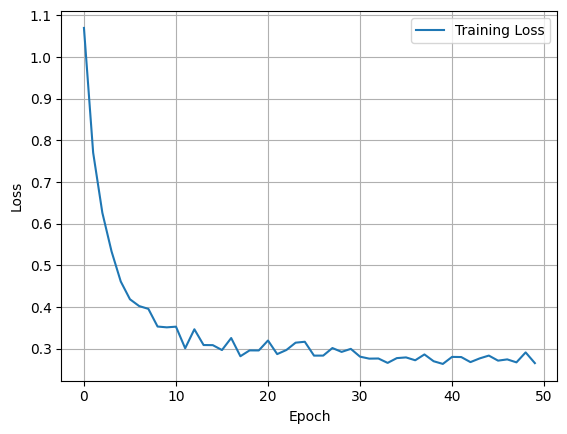

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Directory of checkpoints savings / logs / samples savings / graphs savings 
# Should be iterated to the latest version of the model 
log_dir = "lightning_logs/version_0"

# Plotting the training loss
metrics = pd.read_csv(f"{log_dir}/metrics.csv")
epoch_train_loss = metrics['train_loss_epoch'].dropna().values
# epoch_val_loss = metrics['val_loss'].dropna().values
plt.plot(epoch_train_loss, label='Training Loss')
# plt.plot(epoch_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.plot()
plt.show()

## Comparing results

### Generating samples

In [6]:
import torch
import glob
from opensynth.models.energydiff import calibrate

def create_samples(data_module, dir, place, batch_size, num_samples = 200):
    # Load checkpoint
    ckpt_path = glob.glob(f"{dir}/checkpoints/*.ckpt")[0]
    df_model = diffusion.PLDiffusion1D.load_from_checkpoint(ckpt_path,)

    # sample
    ema_df_model = df_model.ema.ema_model # GaussianDiffusion1D
    dpm_samples = ema_df_model.dpm_solver_sample(total_num_sample=num_samples, batch_size=batch_size, step=100, shape=(24, 1))
    dpm_kwh = data_module.reconstruct_kwh(dpm_samples.squeeze(-1))
    train_kwh = torch.cat([batch['kwh'] for batch in data_module.train_dataloader()])
    train_kwh = dm.reconstruct_kwh(train_kwh)

    # calibration
    dpm_kwh_calib = torch.tensor(calibrate.calibrate(train_kwh, dpm_kwh).to('cpu'))

    # save samples
    os.makedirs(f"{dir}/{place}", exist_ok=True)
    torch.save(dpm_kwh.cpu(), f"{dir}/{place}/dpm_kwh.pt")
    torch.save(dpm_kwh_calib.cpu(), f"{dir}/{place}/dpm_kwh_calib.pt")

sampling batch 1/8,                     batch size 64. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:06<00:00, 15.09it/s]


sampling batch 2/8,                     batch size 64. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:08<00:00, 12.17it/s]


sampling batch 3/8,                     batch size 64. 


...

multistep_dpm_solver_update: 100%|██████████| 98/98 [00:07<00:00, 12.29it/s]


sampling batch 7/8,                     batch size 64. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:08<00:00, 11.50it/s]


sampling batch 8/8,                     batch size 27. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:05<00:00, 17.53it/s]


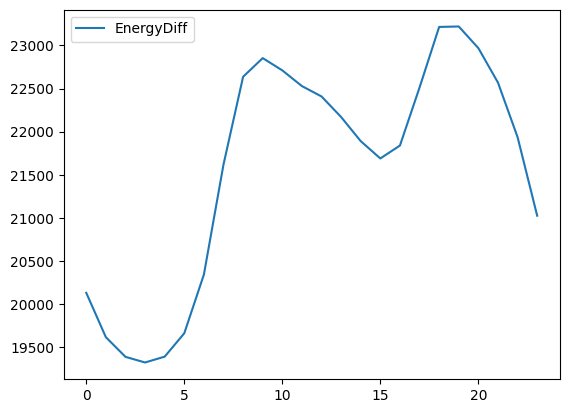

In [8]:
# 25% of the whole dataset is in the holdout for evaluation this roughly corresponds to 0.3*n_training_samples
# so we generate this number of samples
create_samples(dm, log_dir, "samples_0", batch_size=batch_size, num_samples=int(0.3*n_training_samples))

dpm_kwh_calib = torch.load(f'{log_dir}/samples_0/dpm_kwh_calib.pt')

# Plotting the mean of the samples
plt.plot(dpm_kwh_calib.mean(dim=0).cpu().numpy(), label='EnergyDiff')
plt.legend()
plt.show()

In [9]:
eval_data_module = GridFMDataModule(data_path=holdout_data_path, stats_path=stats_path, batch_size=batch_size, n_samples=int(0.3*n_training_samples))
eval_data_module.setup()

# We use all batches of the holdout dataset for evaluation as the dataset is small 
real_data = torch.cat([batch['kwh'] for batch in eval_data_module.train_dataloader()])
real_data = eval_data_module.reconstruct_kwh(real_data)
real_data = torch.clip(real_data, min=0) # Clip min 0 to get rid of negative values

### Comparing mean, 95th quantile, median profiles

In [12]:
from sklearn.metrics import mean_absolute_percentage_error as mape

def plot_stats(real_data, syn_reconstruct, unit = "MW"):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 3), sharey=True, gridspec_kw={'wspace': 0.05})

    real_mean = real_data.mean(dim=0).detach().numpy()
    syn_mean = syn_reconstruct.mean(dim=0).detach().numpy()
    ax1.plot(real_mean, label=f"real {unit}")
    ax1.plot(syn_mean, label=f"energydiff {unit}")
    ax1.set_title(f"Mean {unit} per half hour")
    ax1.set_xlabel("Settlement Periods")
    ax1.text(0.1, -0.5, "MAPE : " + str(round(mape(real_mean, syn_mean), 3)) 
             + "\nMean error : " + str(round((real_mean - syn_mean).mean())) + unit
             + "\nMax error : " + str(round((real_mean - syn_mean).max())) + unit, 
                                             transform=ax1.transAxes)
    ax1.legend()

    real_quantile = real_data.quantile(0.95, dim=0).detach().numpy()
    syn_quantile = syn_reconstruct.quantile(0.95, dim=0).detach().numpy()
    ax2.plot(real_quantile, label=f"real {unit}")
    ax2.plot(syn_quantile, label=f"energydiff {unit}")
    ax2.set_title(f"95th Quantile {unit} per half hour")
    ax2.set_xlabel("Settlement Periods")
    ax2.text(0.1, -0.5, "MAPE : " + str(round(mape(real_quantile, syn_quantile), 3)) 
             + "\nMean error : " + str(round((real_quantile - syn_quantile).mean())) + unit
             + "\nMax error : " + str(round((real_quantile - syn_quantile).max())) + unit, 
                                             transform=ax2.transAxes)
    ax2.legend()

    real_median = real_data.quantile(0.5, dim=0).detach().numpy()
    syn_median = syn_reconstruct.quantile(0.5, dim=0).detach().numpy()
    ax3.plot(real_median, label=f"real {unit}")
    ax3.plot(syn_median, label=f"energydiff {unit}")
    ax3.set_title(f"Median {unit} per half hour")
    ax3.set_xlabel("Settlement Periods")
    ax3.text(0.1, -0.5, "MAPE : " + str(round(mape(real_median, syn_median), 3))
             + "\nMean error : " + str(round((real_median - syn_median).mean())) + unit
             + "\nMax error : " + str(round((real_median - syn_median).max())) + unit, 
                                             transform=ax3.transAxes)
    ax3.legend()
    fig.text(0.08, 0.5, unit, va='center', rotation='vertical')
    fig.tight_layout()
    
    return fig

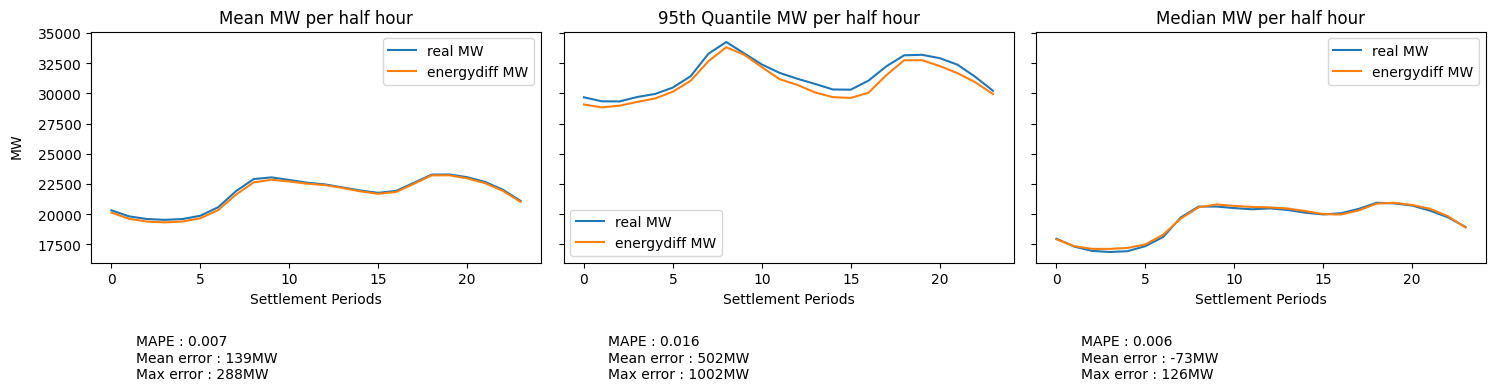

In [13]:
fig = plot_stats(real_data, dpm_kwh_calib)
plt.show()

### PCA and TSNE Distribution

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

def train_pca_and_tsne(real_data, syn_reconstruct):
    pca = PCA(n_components=2)
    tsne = TSNE(n_components=2, perplexity=min(30, len(real_data)))

    pca.fit(real_data.detach().numpy())
    pca_real = pca.transform(real_data.detach().numpy())
    pca_syn = pca.transform(syn_reconstruct.detach().numpy())

    tsne_input = np.concatenate([real_data.detach().numpy(), syn_reconstruct.detach().numpy()])
    tsne_results = tsne.fit_transform(tsne_input)
    tsne_real = tsne_results[:len(real_data)]
    tsne_syn = tsne_results[len(real_data):]

    return pca_real, pca_syn, tsne_real, tsne_syn


def plot_pca_tsne(pca_real, pca_syn, tsne_real, tsne_syn, unit = "kWh"):
    fig, (ax_pca, ax_tsne) = plt.subplots(1, 2, figsize=(12, 4))

    ax_pca.scatter(pca_real[:, 0], pca_real[:, 1], label=f"real {unit}", s=0.3, alpha=0.5)
    ax_pca.scatter(pca_syn[:, 0], pca_syn[:, 1], label=f"energydiff {unit}", s=0.3, alpha=0.5)
    ax_pca.set_title("PCA")
    ax_pca.set_xlabel("PCA 1")
    ax_pca.set_ylabel("PCA 2")
    ax_pca.legend()

    ax_tsne.scatter(tsne_real[:, 0], tsne_real[:, 1], label=f"real {unit}", s=0.3, alpha=0.5)
    ax_tsne.scatter(tsne_syn[:, 0], tsne_syn[:, 1], label=f"energydiff {unit}", s=0.3, alpha=0.5)
    ax_tsne.set_title("TSNE")
    ax_tsne.set_xlabel("TSNE 1")
    ax_tsne.set_ylabel("TSNE 2")
    ax_tsne.legend()
    
    return fig

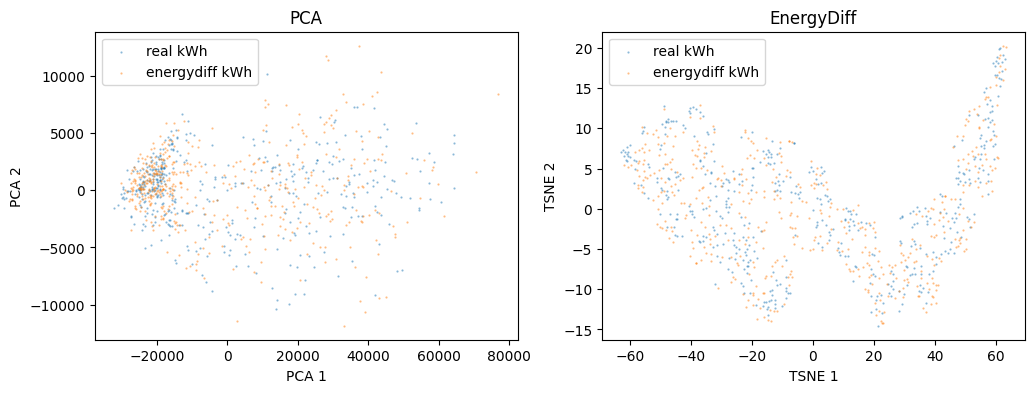

In [15]:
a1, a2, a3, a4 = train_pca_and_tsne(real_data, dpm_kwh_calib)
fig = plot_pca_tsne(a1, a2, a3, a4)
plt.title("EnergyDiff")
plt.show()

### Distribution metrics

In [16]:
from scipy.stats import entropy
from scipy.stats import wasserstein_distance
from scipy.stats import kstest

kl_div = []
wasserstein_dist = []
ks_dist = []

for i in range(real_data.shape[1]):
    real_hist, _ = np.histogram(real_data[:, i], bins=500)
    syn_hist, _ = np.histogram(dpm_kwh_calib[:, i], bins=500)
    kl_div.append(float(round(entropy(real_hist + 1e-10, syn_hist + 1e-10), 3)))
    wasserstein_dist.append(float(round(wasserstein_distance(real_data[:, i], dpm_kwh_calib[:, i]), 3)))
    ks_dist.append(float(round(kstest(real_data[:, i], dpm_kwh_calib[:, i]).statistic, 3)))


print(f"KL Divergence (par pas de temps) : {kl_div}\n")
print(f"Min;Max;Mean KL div : {min(kl_div), max(kl_div), str(round(np.mean(kl_div), 3))} \n")
print(f"Wasserstein Distance (par pas de temps) : {wasserstein_dist}\n")
print(f"Min;Max;Mean Wasserstein dist : {min(wasserstein_dist), max(wasserstein_dist), str(round(np.mean(wasserstein_dist), 3))}\n")
print(f"KS Distance (par pas de temps) : {ks_dist}\n")
print(f"Min;Max;Mean KS dist : {min(ks_dist), max(ks_dist), str(round(np.mean(ks_dist), 3))}\n")

KL Divergence (par pas de temps) : [5.75, 5.574, 5.983, 5.217, 5.667, 5.622, 5.722, 6.401, 5.953, 5.089, 5.223, 4.768, 5.193, 5.06, 4.478, 5.081, 5.236, 6.91, 5.479, 5.865, 5.292, 5.011, 6.023, 5.513]

Min;Max;Mean KL div : (4.478, 6.91, '5.505') 

Wasserstein Distance (par pas de temps) : [259.449, 267.36, 272.76, 284.333, 288.886, 292.667, 317.412, 357.074, 334.756, 278.989, 244.286, 208.823, 205.661, 227.136, 231.79, 240.899, 248.143, 249.431, 242.635, 223.332, 209.29, 197.778, 199.53, 190.287]

Min;Max;Mean Wasserstein dist : (190.287, 357.074, '253.029')

KS Distance (par pas de temps) : [0.041, 0.044, 0.044, 0.047, 0.046, 0.046, 0.049, 0.051, 0.046, 0.049, 0.036, 0.034, 0.029, 0.035, 0.031, 0.043, 0.036, 0.035, 0.039, 0.033, 0.032, 0.032, 0.032, 0.03]

Min;Max;Mean KS dist : (0.029, 0.051, '0.039')

